In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



In [14]:
df = pd.read_parquet("hf://datasets/ncbi/TrialGPT-Criterion-Annotations/data/train-00000-of-00001.parquet")

In [15]:
df.head (2)

,annotation_id,patient_id,note,trial_id,trial_title,criterion_type,criterion_text,gpt4_explanation,explanation_correctness,gpt4_sentences,expert_sentences,gpt4_eligibility,expert_eligibility,training
0,0,sigir-20141,0. A 58-year-old African-American woman presen...,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolo...,inclusion,Patients of chronic stable angina with abnorma...,The patient note does not provide direct evide...,Correct,"[0, 1, 2]","[0, 1, 2]",not enough information,not enough information,True
1,1,sigir-20141,0. A 58-year-old African-American woman presen...,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolo...,inclusion,Male and female,The patient is identified as a female in the n...,Correct,[0],[0],included,included,True


In [16]:
df['expert_eligibility'].value_counts()

expert_eligibility
not excluded              484
not enough information    293
included                  150
not applicable             55
not included               23
excluded                   10
Name: count, dtype: int64

In [17]:
df['expert_eligibility'].value_counts().sum()

1015

In [18]:
(df["explanation_correctness"].value_counts(normalize=True) * 100).round(2)

explanation_correctness
Correct              87.78
Partially Correct     9.66
Incorrect             2.56
Name: proportion, dtype: float64

In [19]:
df["explanation_correctness"].value_counts()

explanation_correctness
Correct              891
Partially Correct     98
Incorrect             26
Name: count, dtype: int64

In [20]:
ground_truth=df['expert_eligibility']
predictions=df['gpt4_eligibility']

In [21]:
print(classification_report(ground_truth,predictions))

                        precision    recall  f1-score   support

              excluded       0.62      1.00      0.77        10
              included       0.97      0.90      0.93       150
        not applicable       0.45      0.98      0.62        55
not enough information       0.88      0.87      0.88       293
          not excluded       0.97      0.86      0.91       484
          not included       0.69      0.78      0.73        23

              accuracy                           0.87      1015
             macro avg       0.77      0.90      0.81      1015
          weighted avg       0.91      0.87      0.88      1015



In [22]:
accuracy_score(ground_truth,predictions)


0.8729064039408867

In [23]:
f1_weighted = f1_score(
    ground_truth,
    predictions,
    average="weighted",
    zero_division=0
)

print("Weighted F1:", round(f1_weighted, 3))

Weighted F1: 0.883


In [24]:
confusion_matrix(ground_truth,predictions)

array([[ 10,   0,   0,   0,   0,   0],
       [  0, 135,   0,  14,   0,   1],
       [  0,   0,  54,   0,   1,   0],
       [  1,   2,  17, 255,  11,   7],
       [  5,   0,  48,  17, 414,   0],
       [  0,   2,   0,   3,   0,  18]], dtype=int64)

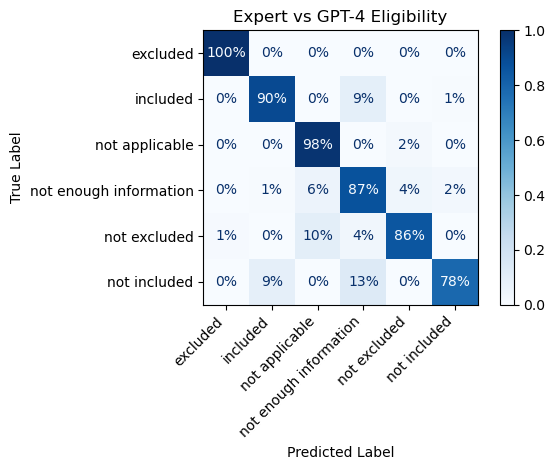

In [25]:
ConfusionMatrixDisplay.from_predictions(
    ground_truth,
    predictions,
    normalize="true",
    values_format=".0%",
    cmap="Blues"
)

plt.title("Expert vs GPT-4 Eligibility")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


In [26]:
df.columns

Index(['annotation_id', 'patient_id', 'note', 'trial_id', 'trial_title',
       'criterion_type', 'criterion_text', 'gpt4_explanation',
       'explanation_correctness', 'gpt4_sentences', 'expert_sentences',
       'gpt4_eligibility', 'expert_eligibility', 'training'],
      dtype='object')

In [27]:
df['explanation_correctness'].value_counts()

explanation_correctness
Correct              891
Partially Correct     98
Incorrect             26
Name: count, dtype: int64

In [28]:
explanation_accuracy=(df['explanation_correctness']=='Correct').mean()

In [29]:
explanation_accuracy

0.8778325123152709

In [30]:
df[['gpt4_sentences','expert_sentences']].head(10)

,gpt4_sentences,expert_sentences
0,"[0, 1, 2]","[0, 1, 2]"
1,[0],[0]
2,[0],[0]
3,[8],[8]
4,[8],[8]
5,[],[]
6,[],[]
7,[],[]
8,"[0, 1, 2]","[0, 1, 2]"
9,[],[]


In [31]:
# Number of macthes and mismatches
mask = df['gpt4_sentences'].eq(df['expert_sentences'], fill_value="")

n_matches    = int(mask.sum())
n_mismatches = int((~mask).sum())
pct_match    = round(mask.mean(), 3)

print(n_matches, n_mismatches, pct_match)

df['is_match'] = mask


956 59 0.942


In [32]:
df['explanation_correctness'].value_counts()

explanation_correctness
Correct              891
Partially Correct     98
Incorrect             26
Name: count, dtype: int64

In [33]:
incorrect_explanations=df[df['explanation_correctness']=='Incorrect']

In [34]:
incorrect_explanations

,annotation_id,patient_id,note,trial_id,trial_title,criterion_type,criterion_text,gpt4_explanation,explanation_correctness,gpt4_sentences,expert_sentences,gpt4_eligibility,expert_eligibility,training,is_match
20,20,sigir-20141,0. A 58-year-old African-American woman presen...,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolo...,exclusion,Geographical inaccessibility for treatment or ...,The patient note does not provide information ...,Incorrect,[],[8],not enough information,not excluded,False,False
25,25,sigir-20141,0. A 58-year-old African-American woman presen...,NCT00149227,Add-on Effects of Valsartan on Morbi- Mortalit...,exclusion,Severe/malignant/secondary hypertensive patients,"The patient is known to have hypertension, but...",Incorrect,[3],[3],not enough information,not excluded,False,True
26,26,sigir-20141,0. A 58-year-old African-American woman presen...,NCT00149227,Add-on Effects of Valsartan on Morbi- Mortalit...,exclusion,Pregnant women and women of childbearing poten...,The patient note does not mention any informat...,Incorrect,[0],[0],not excluded,not enough information,False,True
34,34,sigir-20142,0. An 8-year-old male presents in March to the...,NCT02618655,Clinical Research for the Diagnosis of Tick-bo...,exclusion,fever for non-infectious diseases such as rheu...,The patient note does not mention any non-infe...,Incorrect,[],[],not applicable,not excluded,False,True
36,36,sigir-20142,0. An 8-year-old male presents in March to the...,NCT02618655,Clinical Research for the Diagnosis of Tick-bo...,exclusion,patients leave with automatic discharge,The patient note does not mention anything abo...,Incorrect,[],[],not applicable,not enough information,False,True
44,44,sigir-20143,0. A 58-year-old nonsmoker white female with m...,NCT01452971,A Study of the Interaction Between Tumor Susce...,exclusion,Participant is under 18 years old.,"The patient is 58 years old, which is above th...",Incorrect,[],[0],not applicable,not excluded,False,False
108,108,sigir-20146,0. 64-year-old obese female with diagnosis of ...,NCT02512159,Skin Ulcers Treatment With an Handicraft Topic...,exclusion,Hemodynamically unstable patients.,This criterion is not applicable as there is n...,Incorrect,[],[],not applicable,not excluded,False,True
109,109,sigir-20146,0. 64-year-old obese female with diagnosis of ...,NCT02512159,Skin Ulcers Treatment With an Handicraft Topic...,exclusion,Patients with septic shock from any source.,This criterion is not applicable as there is n...,Incorrect,[],[],not applicable,not excluded,False,True
111,111,sigir-20146,0. 64-year-old obese female with diagnosis of ...,NCT02512159,Skin Ulcers Treatment With an Handicraft Topic...,exclusion,Patients with secondary cutaneous ulcer entera...,This criterion is not applicable as there is n...,Incorrect,[],[],not applicable,not excluded,False,True
115,115,sigir-20146,0. 64-year-old obese female with diagnosis of ...,NCT02512159,Skin Ulcers Treatment With an Handicraft Topic...,exclusion,"Patients with cutaneous ulcer leishmania, inse...",This criterion is not applicable as there is n...,Incorrect,[],"[2, 3]",not applicable,not excluded,False,False


## Human annotation

In [35]:
df_human = pd.read_excel(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_trialgpt\trialgpt_human_annotation.xlsx")

In [36]:
distribution = df_human["human_assessor"].value_counts(dropna=False)
print(distribution)
print("Total:", distribution.sum())

human_assessor
criteria_misinterpretation    56
assumption                    27
other                         24
complete                      10
logical_error                  4
extraction_error               3
Name: count, dtype: int64
Total: 124


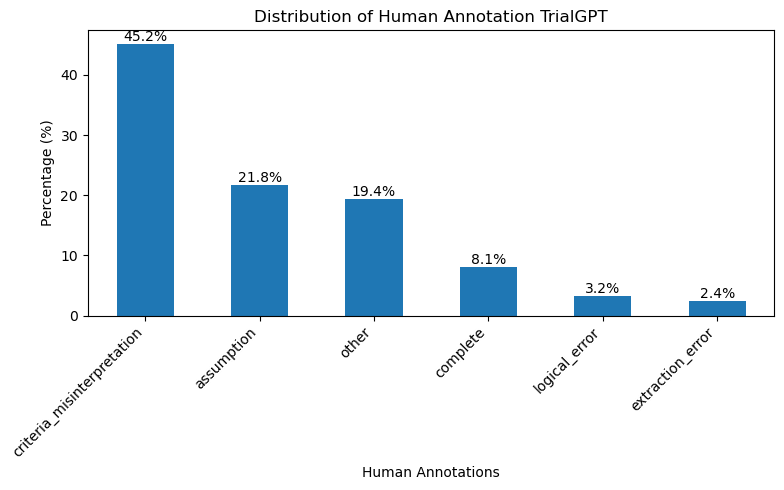

In [37]:
percentages = df_human["human_assessor"].value_counts(dropna=False, normalize=True) * 100

ax = percentages.plot(kind="bar", figsize=(8, 5))

plt.title("Distribution of Human Annotation TrialGPT")
plt.xlabel("Human Annotations")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(percentages.values):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("human_assessor_distribution_trial_gpt.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
distribution = df_human["human_assessor"].value_counts(dropna=False)
print(distribution)
print("Total:", distribution.sum())

human_assessor
criteria_misinterpretation    56
assumption                    27
other                         24
complete                      10
logical_error                  4
extraction_error               3
Name: count, dtype: int64
Total: 124


In [39]:
dist = pd.crosstab(
    df_human["explanation_correctness"],
    df_human["human_assessor"],
    normalize="index"
) * 100

print(dist.round(2))

human_assessor           assumption  complete  criteria_misinterpretation  \
explanation_correctness                                                     
Incorrect                     26.92     19.23                       11.54   
Partially Correct             20.41      5.10                       54.08   

human_assessor           extraction_error  logical_error  other  
explanation_correctness                                          
Incorrect                           11.54          15.38  15.38  
Partially Correct                    0.00           0.00  20.41  


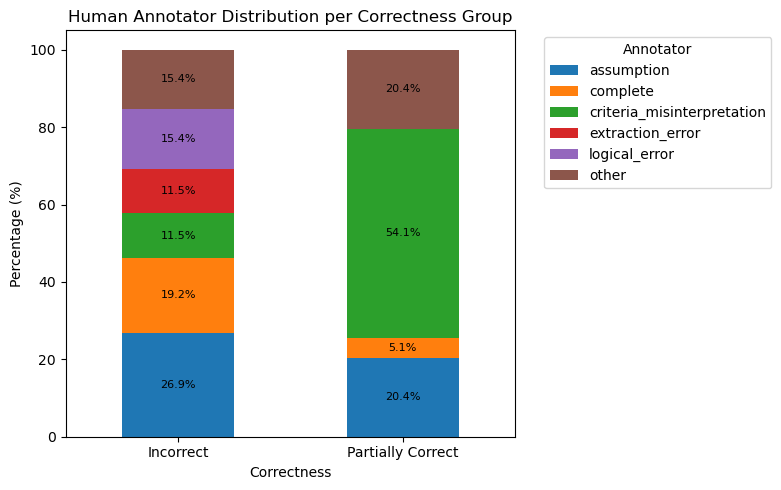

In [40]:
ax = dist.plot(kind="bar", stacked=True, figsize=(8, 5))

plt.title("Human Annotator Distribution per Correctness Group")
plt.xlabel("Correctness")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.1f}%" if v > 0 else "" for v in container.datavalues],
        label_type="center",
        fontsize=8
    )

plt.legend(title="Annotator", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig("annotator_vs_correctness.png", dpi=300)
plt.show()

In [41]:
distribution = df_human["human_confidence"].value_counts(dropna=False)
print(distribution)
print("Total:", distribution.sum())

human_confidence
medium    62
high      41
low       16
low        5
Name: count, dtype: int64
Total: 124


In [42]:
confidence_clean = (
    df_human["human_confidence"]
    .astype("string")
    .str.strip()
)

# Count and percentage
distribution_df = pd.DataFrame({
    "count": confidence_clean.value_counts(dropna=False),
    "percentage": confidence_clean.value_counts(dropna=False, normalize=True).mul(100).round(2)
})

display(distribution_df)

print("Total:", distribution_df["count"].sum())
print("Percentage total:", distribution_df["percentage"].sum().round(2))

,count,percentage
human_confidence,,
medium,62,50.0
high,41,33.06
low,21,16.94


Total: 124
Percentage total: 100.0


## Majority Vote 

## gpt-4o

In [43]:
df_1 = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_trialgpt\trialgpt_results_gpt4o_run_1.csv")
df_2 = pd.read_csv( r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_trialgpt\trialgpt_results_gpt4o_run_3.csv")
df_3 = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_trialgpt\trialgpt_results_gpt4o_run_2.csv")

In [44]:
distribution = df_1["rationale_category"].value_counts(dropna=False)
print(distribution)
print("Total:", distribution.sum())

rationale_category
assumption                    93
extraction_error              22
rational_correct               5
logical_error                  3
criteria_misinterpretation     1
Name: count, dtype: int64
Total: 124


In [45]:
distribution = df_2["rationale_category"].value_counts(dropna=False)
print(distribution)
print("Total:", distribution.sum())

rationale_category
assumption                    94
extraction_error              21
rational_correct               5
logical_error                  3
criteria_misinterpretation     1
Name: count, dtype: int64
Total: 124


In [46]:
distribution = df_3["rationale_category"].value_counts(dropna=False)
print(distribution)
print("Total:", distribution.sum())

rationale_category
assumption                    93
extraction_error              22
rational_correct               5
logical_error                  3
criteria_misinterpretation     1
Name: count, dtype: int64
Total: 124


In [47]:
def take_majority_vote(df1, df2, df3):
    # Set annotation_id as index if it is still a normal column
    df1 = df1.set_index("annotation_id")
    df2 = df2.set_index("annotation_id")
    df3 = df3.set_index("annotation_id")

    # Check that all dataframes have the same annotation_id index
    if not (df1.index.equals(df2.index) and df1.index.equals(df3.index)):
        raise ValueError("df1, df2, and df3 do not have the same annotation_id values/order")

    final_df = df1.copy()

    # Collect the three votes
    votes = pd.concat(
        [
            df1["rationale_category"],
            df2["rationale_category"],
            df3["rationale_category"]
        ],
        axis=1
    )

    votes.columns = ["df1_vote", "df2_vote", "df3_vote"]

    # Take majority vote
    final_df["rationale_category"] = votes.mode(axis=1)[0]

    # Bring annotation_id back as a normal column
    final_df = final_df.reset_index()

    return final_df

In [48]:
df_trialgpt = take_majority_vote(df_1, df_2, df_3)

In [49]:
distribution = df_trialgpt ["rationale_category"].value_counts(dropna=False)
print(distribution)
print("Total:", distribution.sum())

rationale_category
assumption                    94
extraction_error              21
rational_correct               4
logical_error                  3
criteria_misinterpretation     2
Name: count, dtype: int64
Total: 124


In [50]:
distribution = df_trialgpt["rationale_confidence"].value_counts(dropna=False)
print(distribution)
print("Total:", distribution.sum())

rationale_confidence
high      62
medium    62
Name: count, dtype: int64
Total: 124


In [51]:
dist = pd.crosstab(
    df_trialgpt["correctness_group"],
    df_trialgpt["rationale_category"],
    normalize="index"
) * 100

dist = dist.round(2)

display(
    dist.style
    .set_caption("Distribution of Rationale Categories by Correctness Group (%)")
    .format("{:.2f}%")
    .background_gradient(axis=None)
)

rationale_category,assumption,criteria_misinterpretation,extraction_error,logical_error,rational_correct
correctness_group,,,,,
incorrect,15.38%,0.00%,73.08%,11.54%,0.00%
partial,91.84%,2.04%,2.04%,0.00%,4.08%


## gpt4o-mini

In [52]:
df_1_mini = pd.read_csv(r"D:\Downloads\trialgpt_results_gpt4o_run_mini1.csv")
df_2_mini = pd.read_csv( r"D:\Downloads\trialgpt_results_gpt4o_run_mini2.csv")
df_3_mini = pd.read_csv(r"D:\Downloads\trialgpt_results_gpt4o_run_mini3.csv")

In [53]:
df_trialgpt_mini = take_majority_vote(df_1_mini, df_2_mini, df_3_mini)

In [54]:
distribution = df_trialgpt_mini ["rationale_category"].value_counts(dropna=False)

print(distribution)
print("Total:", distribution.sum())

rationale_category
assumption                    61
criteria_misinterpretation    40
extraction_error              20
logical_error                  3
Name: count, dtype: int64
Total: 124


In [55]:
dist = pd.crosstab(
    df_trialgpt_mini["correctness_group"],
    df_trialgpt_mini["rationale_category"],
    normalize="index"
) * 100

dist = dist.round(2)

display(
    dist.style
    .set_caption("Distribution of Rationale Categories by Correctness Group (%)")
    .format("{:.2f}%")
    .background_gradient(axis=None)
)

rationale_category,assumption,criteria_misinterpretation,extraction_error,logical_error
correctness_group,,,,
incorrect,26.92%,0.00%,61.54%,11.54%
partial,55.10%,40.82%,4.08%,0.00%


In [56]:
distribution = df_trialgpt_mini["rationale_confidence"].value_counts(dropna=False)
print(distribution)
print("Total:", distribution.sum())

rationale_confidence
medium    108
high       16
Name: count, dtype: int64
Total: 124


In [57]:
distribution = (
    df_trialgpt_mini["rationale_confidence"]
    .value_counts(dropna=False, normalize=True)
    .mul(100)
    .round(2)
)

print(distribution)

rationale_confidence
medium    87.1
high      12.9
Name: proportion, dtype: float64


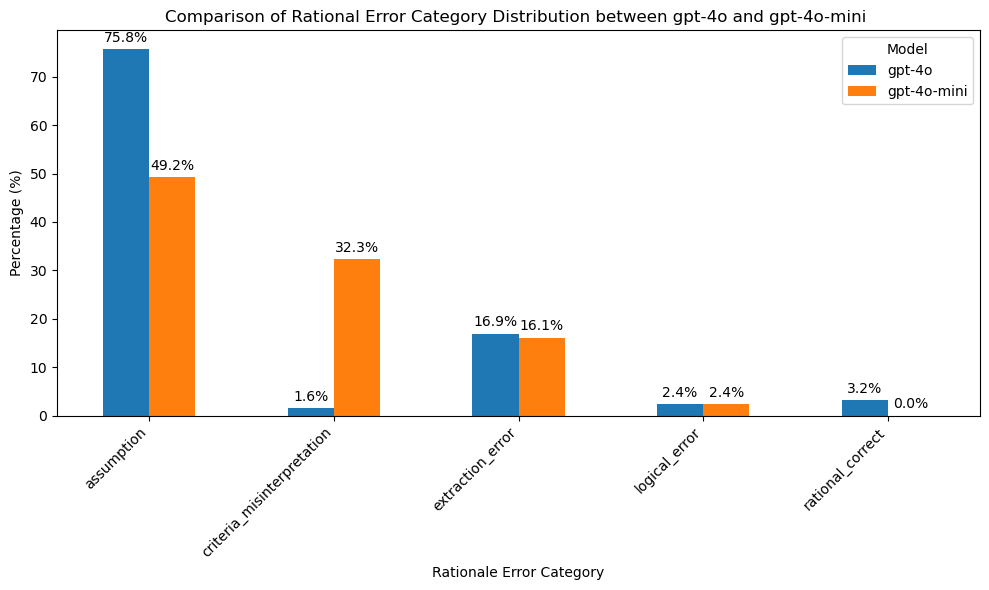

In [58]:
category_col = "rationale_category"

# Calculate percentages for each dataframe
trialgpt_percent = (
    df_trialgpt[category_col]
    .value_counts(normalize=True)
    .mul(100)
)

mini_percent = (
    df_trialgpt_mini[category_col]
    .value_counts(normalize=True)
    .mul(100)
)

# Combine both into one dataframe
compare_dist = pd.DataFrame({
    "gpt-4o": trialgpt_percent,
    "gpt-4o-mini": mini_percent
}).fillna(0)


compare_dist = compare_dist.dropna(how="all")

# Plot grouped bar chart
ax = compare_dist.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Rational Error Category Distribution between gpt-4o and gpt-4o-mini ")
plt.xlabel("Rationale Error Category")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()

# Save figure
plt.savefig(
    "trialgpt_rationale_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Misclassication calculation 

## gpt-4o

In [59]:
df_human_idx = df_human.set_index("annotation_id")
df_trialgpt_idx = df_trialgpt.set_index("annotation_id")

df_combined = df_human_idx.join(
    df_trialgpt_idx,
    how="inner",
    lsuffix="_human",
    rsuffix="_gpt"
)


In [60]:
df_combined.head(2)

,patient_id_human,note_human,trial_id_human,trial_title_human,criterion_type_human,criterion_text_human,gpt4_explanation_human,explanation_correctness_human,gpt4_sentences_human,expert_sentences_human,...,rationale_notes,assessor_evidence_ids,retrieved_count,latency_ms,error,llm_status,llm_error_type,llm_attempts,prompt_tokens,completion_tokens
annotation_id,,,,,,,,,,,,,,,,,,,,,
20,sigir-20141,0. A 58-year-old African-American woman presen...,NCT01397994,Study to Assess Efficacy of Nicorandil+Atenolo...,exclusion,Geographical inaccessibility for treatment or ...,The patient note does not provide information ...,Incorrect,[],[8],...,The model failed to extract or interpret the n...,[],0,1780,NaN,ok,NaN,1,668,90
25,sigir-20141,0. A 58-year-old African-American woman presen...,NCT00149227,Add-on Effects of Valsartan on Morbi- Mortalit...,exclusion,Severe/malignant/secondary hypertensive patients,"The patient is known to have hypertension, but...",Incorrect,[3],[3],...,The model failed to extract or interpret the n...,[],0,1559,NaN,ok,NaN,1,677,97


In [61]:
# labels
y_true = df_combined["human_assessor"]
y_pred = df_combined["rationale_category"]

# weighted F1
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("Weighted F1:", round(f1, 3))

Weighted F1: 0.127


In [62]:
print(classification_report(
    y_true,
    y_pred,
    zero_division=0
))

                            precision    recall  f1-score   support

                assumption       0.24      0.85      0.38        27
                  complete       0.00      0.00      0.00        10
criteria_misinterpretation       1.00      0.04      0.07        56
          extraction_error       0.10      0.67      0.17         3
             logical_error       0.33      0.25      0.29         4
                     other       0.00      0.00      0.00        24
          rational_correct       0.00      0.00      0.00         0

                  accuracy                           0.23       124
                 macro avg       0.24      0.26      0.13       124
              weighted avg       0.52      0.23      0.13       124



In [63]:
for group_name, group_df in df_combined.groupby("explanation_correctness_human"):
    y_true = group_df["human_assessor"]
    y_pred = group_df["rationale_category"]

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("\n" + "="*60)
    print("Explanation correctness group:", group_name)
    print("Number of rows:", len(group_df))
    print("Weighted F1:", round(f1, 3))
    print("-"*60)

    


Explanation correctness group: Incorrect
Number of rows: 26
Weighted F1: 0.212
------------------------------------------------------------

Explanation correctness group: Partially Correct
Number of rows: 98
Weighted F1: 0.114
------------------------------------------------------------


## gpt-4o-mini

In [64]:
df_human_idx = df_human.set_index("annotation_id")
df_trialgpt_idx = df_trialgpt_mini.set_index("annotation_id")

df_combined_mini = df_human_idx.join(
    df_trialgpt_idx,
    how="inner",
    lsuffix="_human",
    rsuffix="_gpt"
)


In [65]:
# labels
y_true = df_combined_mini["human_assessor"]
y_pred = df_combined_mini["rationale_category"]

# weighted F1
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("Weighted F1:", round(f1, 3))

Weighted F1: 0.426


In [ ]:
report = classification_report(
    y_true,
    y_pred,
    zero_division=0,
    output_dict=True
)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Display nicely in notebook
display(report_df.round(3))

# Save to CSV for Excel
report_df.to_csv("classification_report_trial_gpt.csv", index=True)

In [ ]:
for group_name, group_df in df_combined_mini.groupby("explanation_correctness_human"):
    
    eval_df = group_df.dropna(subset=["human_assessor", "rationale_category"])

    y_true = eval_df["human_assessor"].astype(str)
    y_pred = eval_df["rationale_category"].astype(str)

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("\n" + "=" * 60)
    print("Explanation correctness group:", group_name)
    print("Number of rows:", len(eval_df))
    print("Weighted F1:", round(f1, 3))
    print("-" * 60)

    print(classification_report(
        y_true,
        y_pred,
        zero_division=0
    ))

In [ ]:
eval_df = df_combined_mini.dropna(
    subset=["human_assessor", "rationale_category"]
).copy()

# Convert to numpy arrays
y_true = eval_df["human_assessor"].astype(str).to_numpy()
y_pred = eval_df["rationale_category"].astype(str).to_numpy()

# Original weighted F1
original_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

# Bootstrap
n_bootstrap = 1000
rng = np.random.default_rng(42)

bootstrap_f1_scores = []

for _ in range(n_bootstrap):
    sample_idx = rng.choice(
        len(y_true),
        size=len(y_true),
        replace=True
    )

    f1 = f1_score(
        y_true[sample_idx],
        y_pred[sample_idx],
        average="weighted",
        zero_division=0
    )

    bootstrap_f1_scores.append(f1)

bootstrap_f1_scores = np.array(bootstrap_f1_scores)

# 95% confidence interval
lower_ci = np.percentile(bootstrap_f1_scores, 2.5)
upper_ci = np.percentile(bootstrap_f1_scores, 97.5)

print("Weighted F1:", round(original_f1, 3))
print("95% Bootstrap CI:", round(lower_ci, 3), "-", round(upper_ci, 3))

In [ ]:
eval_df = pd.DataFrame({
    "true": y_true,
    "pred": y_pred
})

# Remove missing values and strip spaces
eval_df = eval_df.dropna(subset=["true", "pred"]).copy()
labels = sorted(set(eval_df["true"]) | set(eval_df["pred"]))

# Confusion matrix
cm = confusion_matrix(
    eval_df["true"],
    eval_df["pred"],
    labels=labels
)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()